# Project 5B: Flow Matching from Scratch!
<p style="color: red;"><strong>Note:</strong> You are not required to use the exact .ipynb notebook
         +or format (e.g., you can use a .py or modify the .ipynb however you wish). We only need to see the required deliverables / visualizations.</p>

## Setup environment

In [1]:
# We recommend using these utils.
# https://google.github.io/mediapy/mediapy.html
# https://einops.rocks/
!pip install mediapy einops --quiet

In [2]:
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision.datasets import MNIST
from torchvision.transforms import ToTensor
from tqdm import tqdm
import numpy as np

# Part 1: Training a Single-step Denoising UNet


# Part 1.1: Implementing the UNet

## Implementing Simple and Composed Ops

In [3]:
class Conv(nn.Module):
    """Op (1): Conv2d(3,1,1) + BN + GELU. Same spatial size."""
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.GELU(),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


class DownConv(nn.Module):
    """Op (2): Conv2d(3,2,1) + BN + GELU. Halves spatial size."""
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.GELU(),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


class UpConv(nn.Module):
    """Op (3): ConvTranspose2d(4,2,1) + BN + GELU. Doubles spatial size."""
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(in_channels, out_channels, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.GELU(),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


class Flatten(nn.Module):
    """Op (4): AvgPool2d(7) + GELU. Collapses 7x7 -> 1x1."""
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.AvgPool2d(7),
            nn.GELU(),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


class Unflatten(nn.Module):
    """Op (5): ConvTranspose2d(7,7,0) + BN + GELU. Expands 1x1 -> 7x7."""
    def __init__(self, in_channels: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(in_channels, in_channels, kernel_size=7, stride=7, padding=0),
            nn.BatchNorm2d(in_channels),
            nn.GELU(),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


class ConvBlock(nn.Module):
    """Op (7): Conv -> Conv. Same spatial size."""
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.net = nn.Sequential(
            Conv(in_channels, out_channels),
            Conv(out_channels, out_channels),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


class DownBlock(nn.Module):
    """Op (8): DownConv -> ConvBlock. Halves spatial size."""
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.net = nn.Sequential(
            DownConv(in_channels, out_channels),
            ConvBlock(out_channels, out_channels),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


class UpBlock(nn.Module):
    """Op (9): UpConv -> ConvBlock. Doubles spatial size."""
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.net = nn.Sequential(
            UpConv(in_channels, out_channels),
            ConvBlock(out_channels, out_channels),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)

## Implementing Unconditional UNet

In [4]:
class UnconditionalUNet(nn.Module):
    """
    Unconditional UNet as described in Figure 1 of the spec.
    Input:  (N, 1, 28, 28)
    Output: (N, 1, 28, 28)
    """
    def __init__(self, in_channels: int, num_hiddens: int):
        super().__init__()
        D = num_hiddens

        # Encoder
        self.conv1    = ConvBlock(in_channels, D)        # 28x28 -> 28x28, D ch
        self.down1    = DownBlock(D, 2*D)                # 28x28 -> 14x14, 2D ch
        self.down2    = DownBlock(2*D, 4*D)              # 14x14 -> 7x7,   4D ch
        self.flatten  = Flatten()                        # 7x7   -> 1x1,   4D ch

        # Bottleneck (keeps 4D -> 2D channels for unflatten)
        self.bot_conv = nn.Conv2d(4*D, 2*D, kernel_size=1)

        # Decoder
        self.unflatten = Unflatten(2*D)                  # 1x1   -> 7x7,   2D ch
        self.up1       = UpBlock(2*D + 4*D, 2*D)        # 7x7   -> 14x14, 2D ch (+ skip)
        self.up2       = UpBlock(2*D + 2*D, D)          # 14x14 -> 28x28, D ch  (+ skip)
        self.conv2     = ConvBlock(D + D, D)             # 28x28 -> 28x28, D ch  (+ skip)
        self.out_conv  = nn.Conv2d(D, in_channels, kernel_size=3, stride=1, padding=1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        assert x.shape[-2:] == (28, 28), "Expect input shape to be (28, 28)."

        # Encoder with skip connections
        s1 = self.conv1(x)       # (N, D,  28, 28)
        s2 = self.down1(s1)      # (N, 2D, 14, 14)
        s3 = self.down2(s2)      # (N, 4D,  7,  7)
        b  = self.flatten(s3)    # (N, 4D,  1,  1)
        b  = self.bot_conv(b)    # (N, 2D,  1,  1)

        # Decoder with skip connections via Concat
        u  = self.unflatten(b)                    # (N, 2D,  7,  7)
        u  = self.up1(torch.cat([u,  s3], dim=1)) # (N, 2D, 14, 14)
        u  = self.up2(torch.cat([u,  s2], dim=1)) # (N,  D, 28, 28)
        u  = self.conv2(torch.cat([u, s1], dim=1))# (N,  D, 28, 28)
        return self.out_conv(u)                   # (N,  1, 28, 28)

# Part 1.2: Using the UNet to Train a Denoiser

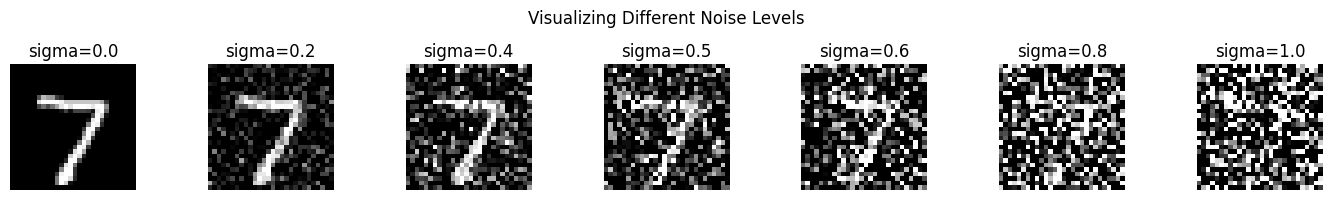

In [5]:
# Visualize images at different noise levels
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

viz_dataset = MNIST(root='./data', train=False, download=True, transform=ToTensor())
sample_img = viz_dataset[0][0]  # (1, 28, 28)

sigmas = [0.0, 0.2, 0.4, 0.5, 0.6, 0.8, 1.0]
fig, axes = plt.subplots(1, len(sigmas), figsize=(14, 2))
for ax, sigma in zip(axes, sigmas):
    noisy = sample_img + sigma * torch.randn_like(sample_img)
    ax.imshow(noisy.squeeze().numpy(), cmap='gray', vmin=0, vmax=1)
    ax.set_title(f'sigma={sigma}')
    ax.axis('off')
plt.suptitle('Visualizing Different Noise Levels')
plt.tight_layout()
plt.show()

## Part 1.2.1: Training

In [6]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

batch_size   = 128
learning_rate = 1e-3
noise_level  = 0.5
hidden_dim   = 64
num_epochs   = 5

In [7]:
train_dataset = MNIST(root='./data', train=True,  download=True, transform=ToTensor())
test_dataset  = MNIST(root='./data', train=False, download=True, transform=ToTensor())
train_loader  = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,  num_workers=2)
test_loader   = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False, num_workers=2)

In [8]:
model     = UnconditionalUNet(in_channels=1, num_hiddens=hidden_dim).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
criterion = nn.MSELoss()

In [9]:
train_losses = []

# Store outputs for deliverable: after epoch 1 and epoch 5
epoch_sample_outputs = {}

for epoch in range(num_epochs):
    model.train()
    for i, (images, _) in enumerate(tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}')):
        images = images.to(device)  # (N, 1, 28, 28) clean
        noisy  = images + noise_level * torch.randn_like(images)  # add noise

        outputs = model(noisy)      # predict clean

        loss = criterion(outputs, images)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())

    # Save sample results after epoch 1 and epoch 5
    if epoch + 1 in [1, num_epochs]:
        model.eval()
        with torch.no_grad():
            test_imgs, _ = next(iter(test_loader))
            test_imgs = test_imgs[:5].to(device)
            noisy_test = test_imgs + noise_level * torch.randn_like(test_imgs)
            denoised = model(noisy_test)
        epoch_sample_outputs[epoch+1] = {
            'clean': test_imgs.cpu(),
            'noisy': noisy_test.cpu(),
            'denoised': denoised.cpu(),
        }

Epoch 5/5: 100%|██████████| 469/469 [00:08<00:00, 56.66it/s]


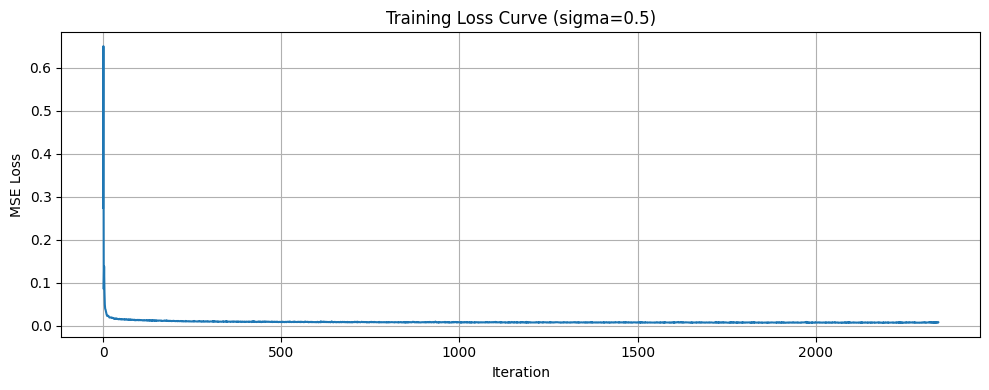

In [10]:
# Visualize training loss curve
plt.figure(figsize=(10, 4))
plt.plot(train_losses)
plt.xlabel('Iteration')
plt.ylabel('MSE Loss')
plt.title(f'Training Loss Curve (sigma={noise_level})')
plt.grid(True)
plt.tight_layout()
plt.show()

### Training Loss Interpretation
The loss should generally trend downward as the model learns to reconstruct the target images. Small fluctuations are normal because each batch contains different noise realizations and different digits, so the optimization problem is stochastic rather than perfectly smooth.

Early in training, the model sees large errors and the curve can drop quickly. Later, the decrease usually slows because the network is refining finer details rather than learning the broad structure.

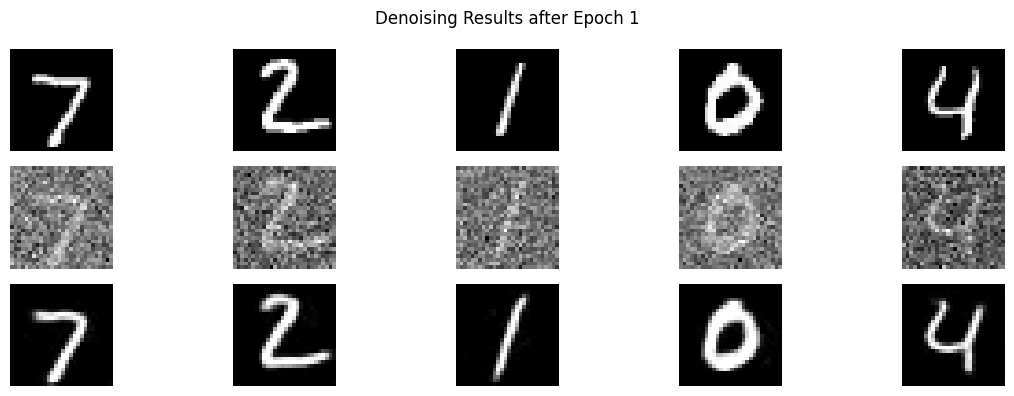

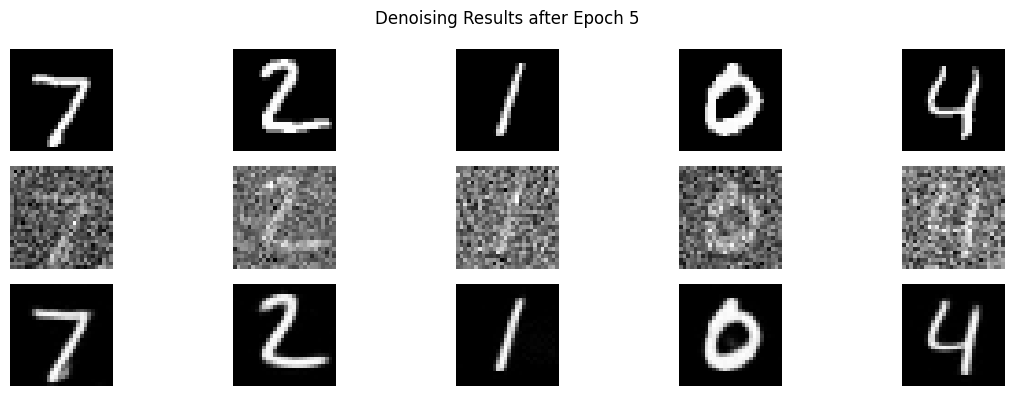

In [11]:
# Visualize sample results after epoch 1 and epoch 5
for ep in [1, num_epochs]:
    data = epoch_sample_outputs[ep]
    n = 5
    fig, axes = plt.subplots(3, n, figsize=(12, 4))
    for j in range(n):
        axes[0, j].imshow(data['clean'][j].squeeze(), cmap='gray', vmin=0, vmax=1)
        axes[1, j].imshow(data['noisy'][j].squeeze(), cmap='gray')
        axes[2, j].imshow(data['denoised'][j].squeeze(), cmap='gray', vmin=0, vmax=1)
        if j == 0:
            axes[0, j].set_ylabel('Clean')
            axes[1, j].set_ylabel(f'Noisy (sigma={noise_level})')
            axes[2, j].set_ylabel('Denoised')
        for ax in axes[:, j]: ax.axis('off')
    plt.suptitle(f'Denoising Results after Epoch {ep}')
    plt.tight_layout()
    plt.show()

## Part 1.2.2: Out-of-Distribution Testing

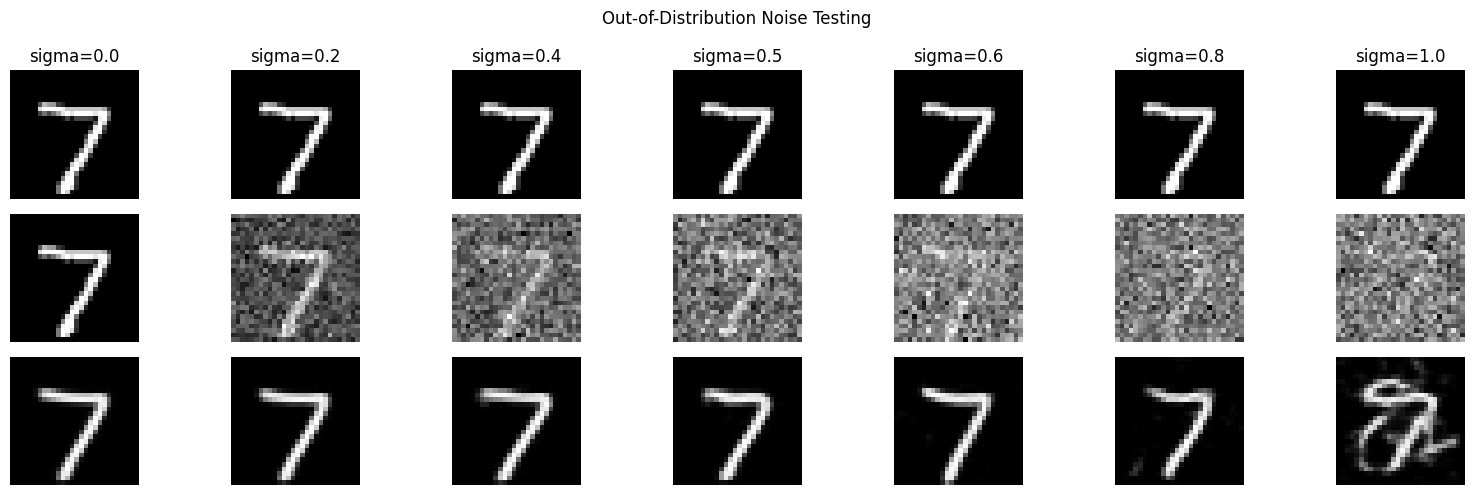

In [12]:
# OOD testing: vary sigma on the same test image
ood_sigmas = [0.0, 0.2, 0.4, 0.5, 0.6, 0.8, 1.0]
test_img, _ = test_dataset[0]
test_img = test_img.unsqueeze(0).to(device)  # (1, 1, 28, 28)

model.eval()
fig, axes = plt.subplots(3, len(ood_sigmas), figsize=(16, 5))
with torch.no_grad():
    for j, sigma in enumerate(ood_sigmas):
        noisy_img = test_img + sigma * torch.randn_like(test_img)
        denoised_img = model(noisy_img)
        axes[0, j].imshow(test_img[0].squeeze().cpu(), cmap='gray', vmin=0, vmax=1)
        axes[1, j].imshow(noisy_img[0].squeeze().cpu(), cmap='gray')
        axes[2, j].imshow(denoised_img[0].squeeze().cpu(), cmap='gray', vmin=0, vmax=1)
        axes[0, j].set_title(f'sigma={sigma}')
        for ax in axes[:, j]: ax.axis('off')

axes[0, 0].set_ylabel('Clean')
axes[1, 0].set_ylabel('Noisy')
axes[2, 0].set_ylabel('Denoised')
plt.suptitle('Out-of-Distribution Noise Testing')
plt.tight_layout()
plt.show()

## Part 1.2.3 Denoising Pure Noise

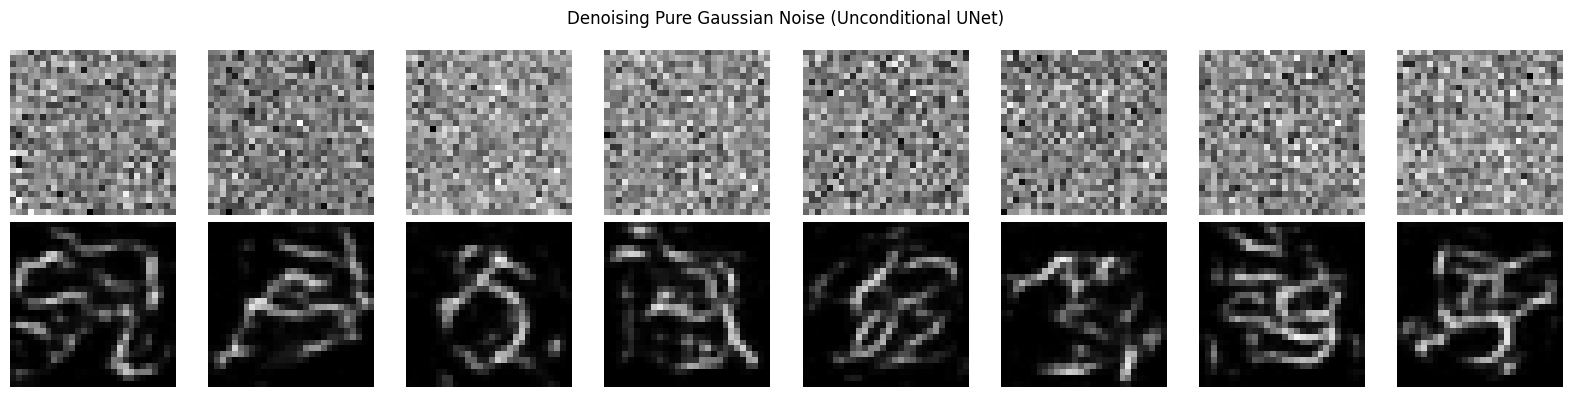

In [13]:
# Denoise pure Gaussian noise (one-step; no iterative refinement)
model.eval()
torch.manual_seed(42)
with torch.no_grad():
    pure_noise = torch.randn(8, 1, 28, 28).to(device)
    generated = model(pure_noise)

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for j in range(8):
    axes[0, j].imshow(pure_noise[j].squeeze().cpu(), cmap='gray')
    axes[1, j].imshow(generated[j].squeeze().cpu(), cmap='gray', vmin=0, vmax=1)
    for ax in axes[:, j]: ax.axis('off')
axes[0, 0].set_ylabel('Pure Noise')
axes[1, 0].set_ylabel('Denoised')
plt.suptitle('Denoising Pure Gaussian Noise (Unconditional UNet)')
plt.tight_layout()
plt.show()

# Part 2: Flow Matching

# Part 2.1: Implementing a Time-conditioned UNet

In [14]:
class FCBlock(nn.Module):
    """
    Op (10): Fully-connected block for injecting conditioning signal.
    Linear(F_in, F_out) + GELU -> Linear(F_out, F_out)
    """
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_channels, out_channels),
            nn.GELU(),
            nn.Linear(out_channels, out_channels),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


class TimeConditionalUNet(nn.Module):
    """
    Time-conditioned UNet as in Figure 4 of the spec.
    Time t is injected via two FCBlocks that modulate the
    unflatten and up1 feature maps.
    Input:  (N, 1, 28, 28) + t (N,)
    Output: (N, 1, 28, 28)
    """
    def __init__(self, in_channels: int, num_hiddens: int):
        super().__init__()
        D = num_hiddens

        # Encoder
        self.conv1    = ConvBlock(in_channels, D)
        self.down1    = DownBlock(D, 2*D)
        self.down2    = DownBlock(2*D, 4*D)
        self.flatten  = Flatten()
        self.bot_conv = nn.Conv2d(4*D, 2*D, kernel_size=1)

        # Time conditioning FCBlocks
        # fc1_t modulates unflatten (2D channels -> one scalar per channel)
        self.fc1_t = FCBlock(1, 2*D)
        # fc2_t modulates up1 (2D channels)
        self.fc2_t = FCBlock(1, 2*D)

        # Decoder
        self.unflatten = Unflatten(2*D)
        self.up1       = UpBlock(2*D + 4*D, 2*D)
        self.up2       = UpBlock(2*D + 2*D, D)
        self.conv2     = ConvBlock(D + D, D)
        self.out_conv  = nn.Conv2d(D, in_channels, kernel_size=3, stride=1, padding=1)

    def forward(self, x: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x: (N, C, H, W) input tensor.
            t: (N,) normalized time tensor in [0, 1].
        Returns:
            (N, C, H, W) output tensor (predicted flow).
        """
        assert x.shape[-2:] == (28, 28), "Expect input shape to be (28, 28)."
        N = x.shape[0]

        # Normalize t and embed
        t_emb = t.view(N, 1)        # (N, 1)
        t1 = self.fc1_t(t_emb)      # (N, 2D)
        t2 = self.fc2_t(t_emb)      # (N, 2D)

        # Encoder
        s1 = self.conv1(x)           # (N, D,  28, 28)
        s2 = self.down1(s1)          # (N, 2D, 14, 14)
        s3 = self.down2(s2)          # (N, 4D,  7,  7)
        b  = self.flatten(s3)        # (N, 4D,  1,  1)
        b  = self.bot_conv(b)        # (N, 2D,  1,  1)

        # Decoder with time modulation
        u  = self.unflatten(b)                        # (N, 2D,  7,  7)
        # Modulate unflatten output with t1
        u  = u * t1.view(N, -1, 1, 1)                # scale by t1
        u  = self.up1(torch.cat([u, s3], dim=1))     # (N, 2D, 14, 14)
        # Modulate up1 output with t2
        u  = u * t2.view(N, -1, 1, 1)                # scale by t2
        u  = self.up2(torch.cat([u, s2], dim=1))     # (N,  D, 28, 28)
        u  = self.conv2(torch.cat([u, s1], dim=1))   # (N,  D, 28, 28)
        return self.out_conv(u)                       # (N,  1, 28, 28)

## Implementing the Forward and Reverse Process for Time-conditioned Denoising

In [15]:
def time_fm_forward(
    unet: TimeConditionalUNet,
    x_1: torch.Tensor,
    num_ts: int,
) -> torch.Tensor:
    """Algorithm B.1: Flow Matching Training step.

    x_1: clean image  (N, C, H, W)
    Returns scalar MSE loss.
    """
    unet.train()
    N = x_1.shape[0]
    device = x_1.device

    # Sample random timestep t ~ Uniform([0,1])
    t = torch.rand(N, device=device)           # (N,)

    # Sample noise x_0 ~ N(0, I)
    x_0 = torch.randn_like(x_1)               # (N, C, H, W)

    # Interpolate: x_t = (1-t)*x_0 + t*x_1
    t_view = t.view(N, 1, 1, 1)
    x_t = (1 - t_view) * x_0 + t_view * x_1  # (N, C, H, W)

    # Target flow: u = x_1 - x_0
    target = x_1 - x_0                        # (N, C, H, W)

    # Predict flow
    pred = unet(x_t, t)                        # (N, C, H, W)

    # MSE loss
    loss = ((pred - target) ** 2).mean()
    return loss

In [16]:
@torch.inference_mode()
def time_fm_sample(
    unet: TimeConditionalUNet,
    img_wh: tuple,
    num_ts: int,
    n_samples: int = 16,
    seed: int = 0,
) -> torch.Tensor:
    """Algorithm B.2: Euler sampling from flow matching model.

    Returns (n_samples, C, H, W) tensor.
    """
    unet.eval()
    device = next(unet.parameters()).device
    H, W = img_wh
    C = 1

    torch.manual_seed(seed)
    x_t = torch.randn(n_samples, C, H, W, device=device)  # x_0 ~ N(0, I)

    dt = 1.0 / num_ts
    # t goes from 0 to 1 in steps of 1/T
    for i in range(num_ts):
        t_val = i / num_ts
        t = torch.full((n_samples,), t_val, device=device)  # (N,)
        u = unet(x_t, t)                                     # predicted flow
        x_t = x_t + dt * u                                  # Euler step

    return x_t  # (N, C, H, W)

In [17]:
class TimeConditionalFM(nn.Module):
    def __init__(self, unet: TimeConditionalUNet, num_ts: int = 50, img_hw: tuple = (28, 28)):
        super().__init__()
        self.unet   = unet
        self.num_ts = num_ts
        self.img_hw = img_hw

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return time_fm_forward(self.unet, x, self.num_ts)

    @torch.inference_mode()
    def sample(self, img_wh: tuple, n_samples: int = 16, seed: int = 0):
        return time_fm_sample(self.unet, img_wh, self.num_ts, n_samples, seed)

# Part 2.2: Training the Time-conditioned UNet

In [18]:
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# # Hyperparameters
# fm_batch_size   = 64
# fm_lr           = 1e-2
# fm_hidden_dim   = 64
# fm_num_epochs   = 10
# fm_num_ts       = 50   # number of Euler steps for sampling

# fm_train_loader = DataLoader(
#     MNIST(root='./data', train=True, download=True, transform=ToTensor()),
#     batch_size=fm_batch_size, shuffle=True, num_workers=2
# )

# # Build model
# fm_unet = TimeConditionalUNet(in_channels=1, num_hiddens=fm_hidden_dim).to(device)
# fm_model = TimeConditionalFM(fm_unet, num_ts=fm_num_ts, img_hw=(28, 28))

# fm_optimizer = torch.optim.Adam(fm_unet.parameters(), lr=fm_lr)
# fm_scheduler = torch.optim.lr_scheduler.ExponentialLR(
#     fm_optimizer, gamma=0.1 ** (1.0 / fm_num_epochs)
# )

# fm_train_losses = []
# fm_epoch_samples = {}

# for epoch in range(fm_num_epochs):
#     fm_unet.train()
#     for images, _ in tqdm(fm_train_loader, desc=f'FM Epoch {epoch+1}/{fm_num_epochs}'):
#         images = images.to(device)

#         loss = fm_model(images)
#         fm_optimizer.zero_grad()
#         loss.backward()
#         fm_optimizer.step()
#         fm_train_losses.append(loss.item())

#     fm_scheduler.step()

#     # Save samples at epoch 1, 5, 10
#     if epoch + 1 in [1, 5, fm_num_epochs]:
#         samples = fm_model.sample(img_wh=(28, 28), n_samples=16, seed=42)
#         fm_epoch_samples[epoch+1] = samples.cpu()

# # Plot training loss
# plt.figure(figsize=(10, 4))
# plt.plot(fm_train_losses)
# plt.xlabel('Iteration')
# plt.ylabel('Flow Matching Loss')
# plt.title('Time-conditioned UNet Training Loss')
# plt.grid(True)
# plt.tight_layout()
# plt.show()

In [19]:
from torch.amp import autocast, GradScaler

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🚀 Device: {device}")

🚀 Device: cuda


📊 Config: batch_size=128, lr=0.01, epochs=10, hidden_dim=64
📦 DataLoader ready: 469 batches
🏗️  Building TimeConditionalUNet...
✅ Model built and moved to cuda

🔥 Starting training with AMP (Mixed Precision)...



FM Epoch 1/10:   0%|          | 0/469 [00:00<?, ?it/s]

FM Epoch 1/10: 100%|██████████| 469/469 [00:17<00:00, 27.35it/s]


✨ Epoch 1/10 completed
   📈 Avg Loss: 0.393134
   🎯 LR: 7.94e-03
📸 Sampling epoch 1 results (16 samples)...
   ✅ Samples saved!


FM Epoch 2/10: 100%|██████████| 469/469 [00:14<00:00, 32.49it/s]


...

✨ Epoch 8/10 completed
   📈 Avg Loss: 0.107622
   🎯 LR: 1.58e-03


FM Epoch 9/10: 100%|██████████| 469/469 [00:14<00:00, 32.34it/s]


✨ Epoch 9/10 completed
   📈 Avg Loss: 0.105556
   🎯 LR: 1.26e-03


FM Epoch 10/10: 100%|██████████| 469/469 [00:14<00:00, 32.62it/s]


✨ Epoch 10/10 completed
   📈 Avg Loss: 0.104273
   🎯 LR: 1.00e-03
📸 Sampling epoch 10 results (16 samples)...
   ✅ Samples saved!

✅ Training complete!

📊 Plotting training loss...


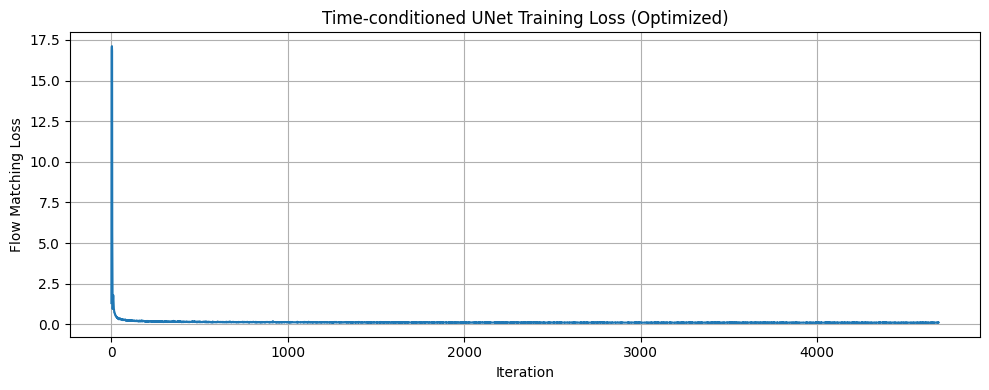

✅ Plot complete!


In [20]:
# Hyperparameters (OPTIMIZED)
fm_batch_size   = 128
fm_lr           = 1e-2
fm_hidden_dim   = 64
fm_num_epochs   = 10
fm_num_ts       = 50

print(f"📊 Config: batch_size={fm_batch_size}, lr={fm_lr}, epochs={fm_num_epochs}, hidden_dim={fm_hidden_dim}")

fm_train_loader = DataLoader(
    MNIST(root='./data', train=True, download=True, transform=ToTensor()),
    batch_size=fm_batch_size, shuffle=True, num_workers=0
)

print(f"📦 DataLoader ready: {len(fm_train_loader)} batches")

# Build model
print("🏗️  Building TimeConditionalUNet...")
fm_unet = TimeConditionalUNet(in_channels=1, num_hiddens=fm_hidden_dim).to(device)
fm_model = TimeConditionalFM(fm_unet, num_ts=fm_num_ts, img_hw=(28, 28))
print(f"✅ Model built and moved to {device}")

fm_optimizer = torch.optim.Adam(fm_unet.parameters(), lr=fm_lr)
fm_scheduler = torch.optim.lr_scheduler.ExponentialLR(
    fm_optimizer, gamma=0.1 ** (1.0 / fm_num_epochs)
)

scaler = GradScaler('cuda')

fm_train_losses = []
fm_epoch_samples = {}

print("\n🔥 Starting training with AMP (Mixed Precision)...\n")

for epoch in range(fm_num_epochs):
    fm_unet.train()
    epoch_loss = 0
    batch_count = 0
    
    for batch_idx, (images, _) in enumerate(tqdm(fm_train_loader, desc=f'FM Epoch {epoch+1}/{fm_num_epochs}')):
        images = images.to(device)

        with autocast('cuda'):
            loss = fm_model(images)
        
        fm_optimizer.zero_grad()
        scaler.scale(loss).backward()
        scaler.step(fm_optimizer)
        scaler.update()
        
        fm_train_losses.append(loss.item())
        epoch_loss += loss.item()
        batch_count += 1

    avg_loss = epoch_loss / batch_count
    fm_scheduler.step()
    
    print(f"✨ Epoch {epoch+1}/{fm_num_epochs} completed")
    print(f"   📈 Avg Loss: {avg_loss:.6f}")
    print(f"   🎯 LR: {fm_optimizer.param_groups[0]['lr']:.2e}")

    # Save samples at epochs 1, 5, and 10
    if epoch + 1 in [1, 5, 10]:
        print(f"📸 Sampling epoch {epoch+1} results (16 samples)...")
        samples = fm_model.sample(img_wh=(28, 28), n_samples=16, seed=42)
        fm_epoch_samples[epoch+1] = samples.cpu()
        print(f"   ✅ Samples saved!")

print("\n✅ Training complete!\n")

# Plot training loss
print("📊 Plotting training loss...")
plt.figure(figsize=(10, 4))
plt.plot(fm_train_losses)
plt.xlabel('Iteration')
plt.ylabel('Flow Matching Loss')
plt.title('Time-conditioned UNet Training Loss (Optimized)')
plt.grid(True)
plt.tight_layout()
plt.show()
print("✅ Plot complete!")

### Training Loss Interpretation
The class-conditioned flow-matching loss should generally decline as the model learns to use both the time signal and the class label. Occasional bumps are expected because classifier-free dropout changes which examples are conditioned, so each batch presents a slightly different optimization problem.

# Part 2.3: Sampling from the Time-conditioned UNet

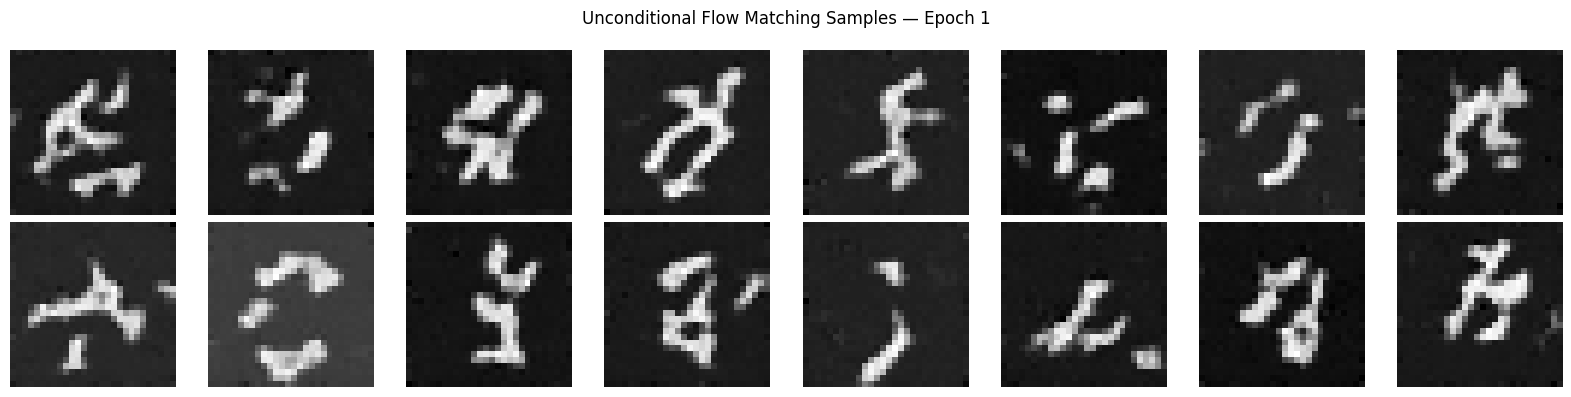

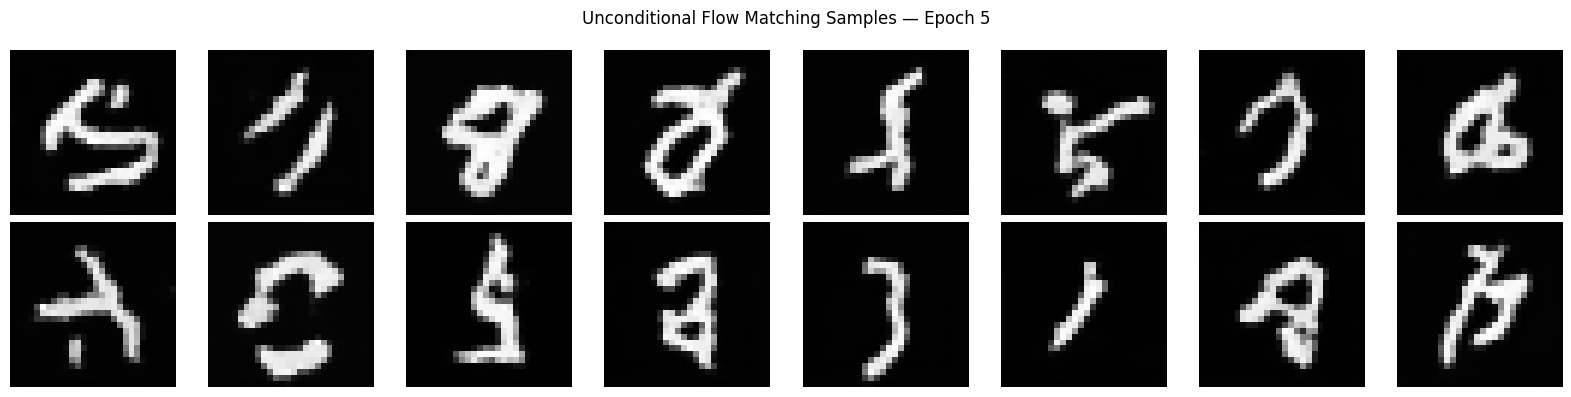

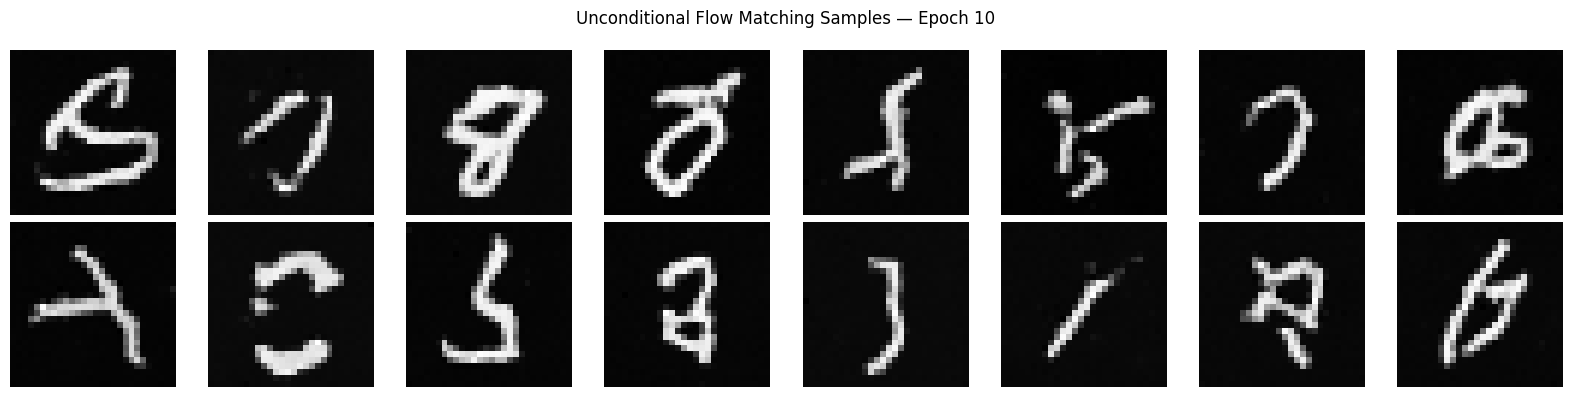

In [21]:
# Visualize generated samples for epochs 1, 5, 10
for ep in [1, 5, 10]:
    if ep not in fm_epoch_samples:
        print(f"Skipping epoch {ep}: samples not available yet.")
        continue

    samples = fm_epoch_samples[ep]
    fig, axes = plt.subplots(2, 8, figsize=(16, 4))
    for j in range(16):
        r, c = j // 8, j % 8
        axes[r, c].imshow(samples[j].squeeze(), cmap='gray')
        axes[r, c].axis('off')
    plt.suptitle(f'Unconditional Flow Matching Samples — Epoch {ep}')
    plt.tight_layout()
    plt.show()
    plt.close(fig)

# Part 2.4: Implementing a Class-conditioned UNet

In [22]:
class ClassConditionalUNet(nn.Module):
    """
    Class + time conditioned UNet.
    Uses 4 FCBlocks: fc1_t, fc1_c, fc2_t, fc2_c.
    Conditioning: unflatten = c1*unflatten + t1, up1 = c2*up1 + t2
    """
    def __init__(self, in_channels: int, num_classes: int, num_hiddens: int):
        super().__init__()
        D = num_hiddens

        # Encoder
        self.conv1    = ConvBlock(in_channels, D)
        self.down1    = DownBlock(D, 2*D)
        self.down2    = DownBlock(2*D, 4*D)
        self.flatten  = Flatten()
        self.bot_conv = nn.Conv2d(4*D, 2*D, kernel_size=1)

        # Time and class FCBlocks
        self.fc1_t = FCBlock(1, 2*D)
        self.fc1_c = FCBlock(num_classes, 2*D)
        self.fc2_t = FCBlock(1, 2*D)
        self.fc2_c = FCBlock(num_classes, 2*D)

        # Decoder
        self.unflatten = Unflatten(2*D)
        self.up1       = UpBlock(2*D + 4*D, 2*D)
        self.up2       = UpBlock(2*D + 2*D, D)
        self.conv2     = ConvBlock(D + D, D)
        self.out_conv  = nn.Conv2d(D, in_channels, kernel_size=3, stride=1, padding=1)

        self.num_classes = num_classes

    def forward(
        self,
        x: torch.Tensor,
        c: torch.Tensor,
        t: torch.Tensor,
        mask: torch.Tensor | None = None,
    ) -> torch.Tensor:
        """
        Args:
            x: (N, C, H, W)
            c: (N,) int64 class labels
            t: (N,) normalized time in [0,1]
            mask: (N,) if provided, zero out class conditioning where mask==0
        """
        assert x.shape[-2:] == (28, 28), "Expect input shape to be (28, 28)."
        N = x.shape[0]
        device = x.device

        # One-hot encode class label
        c_onehot = torch.zeros(N, self.num_classes, device=device)
        c_onehot.scatter_(1, c.view(N, 1), 1.0)  # (N, num_classes)

        # Apply dropout mask for classifier-free guidance
        if mask is not None:
            c_onehot = c_onehot * mask.view(N, 1).float()

        # Embed time and class
        t_emb = t.view(N, 1)          # (N, 1)
        t1 = self.fc1_t(t_emb)        # (N, 2D)
        c1 = self.fc1_c(c_onehot)     # (N, 2D)
        t2 = self.fc2_t(t_emb)        # (N, 2D)
        c2 = self.fc2_c(c_onehot)     # (N, 2D)

        # Encoder
        s1 = self.conv1(x)
        s2 = self.down1(s1)
        s3 = self.down2(s2)
        b  = self.flatten(s3)
        b  = self.bot_conv(b)

        # Decoder with class+time modulation
        u  = self.unflatten(b)                         # (N, 2D, 7, 7)
        u  = c1.view(N, -1, 1, 1) * u + t1.view(N, -1, 1, 1)
        u  = self.up1(torch.cat([u, s3], dim=1))       # (N, 2D, 14, 14)
        u  = c2.view(N, -1, 1, 1) * u + t2.view(N, -1, 1, 1)
        u  = self.up2(torch.cat([u, s2], dim=1))       # (N, D, 28, 28)
        u  = self.conv2(torch.cat([u, s1], dim=1))     # (N, D, 28, 28)
        return self.out_conv(u)                        # (N, 1, 28, 28)

In [23]:
def class_fm_forward(
    unet: ClassConditionalUNet,
    x_1: torch.Tensor,
    c: torch.Tensor,
    p_uncond: float,
    num_ts: int,
) -> torch.Tensor:
    """Algorithm B.3: Class-conditional flow matching training step."""
    unet.train()
    N = x_1.shape[0]
    device = x_1.device

    # Sample t ~ Uniform([0,1])
    t = torch.rand(N, device=device)

    # Sample noise
    x_0 = torch.randn_like(x_1)

    # Interpolate
    t_view = t.view(N, 1, 1, 1)
    x_t = (1 - t_view) * x_0 + t_view * x_1

    # Target flow
    target = x_1 - x_0

    # Dropout mask: with prob p_uncond, drop the class condition
    mask = (torch.rand(N, device=device) >= p_uncond).long()  # (N,)

    # Predict flow
    pred = unet(x_t, c, t, mask=mask)

    loss = ((pred - target) ** 2).mean()
    return loss

In [24]:
@torch.inference_mode()
def class_fm_sample(
    unet: ClassConditionalUNet,
    c: torch.Tensor,
    img_wh: tuple,
    num_ts: int,
    guidance_scale: float = 5.0,
    seed: int = 0,
) -> torch.Tensor:
    """Algorithm B.4: Classifier-free guidance sampling.

    c: (N,) class labels
    Returns (N, C, H, W) samples.
    """
    unet.eval()
    device = next(unet.parameters()).device
    H, W = img_wh
    N = c.shape[0]
    C = 1

    torch.manual_seed(seed)
    x_t = torch.randn(N, C, H, W, device=device)

    dt = 1.0 / num_ts
    # zero mask = unconditional
    zero_mask = torch.zeros(N, device=device, dtype=torch.long)
    # ones mask = conditional
    ones_mask = torch.ones(N, device=device, dtype=torch.long)

    for i in range(num_ts):
        t_val = i / num_ts
        t = torch.full((N,), t_val, device=device)

        u_uncond = unet(x_t, c, t, mask=zero_mask)   # unconditional
        u_cond   = unet(x_t, c, t, mask=ones_mask)   # conditional

        # Classifier-free guidance
        u = u_uncond + guidance_scale * (u_cond - u_uncond)
        x_t = x_t + dt * u

    return x_t  # (N, C, H, W)

In [25]:
class ClassConditionalFM(nn.Module):
    def __init__(self, unet: ClassConditionalUNet, num_ts: int = 300, p_uncond: float = 0.1):
        super().__init__()
        self.unet     = unet
        self.num_ts   = num_ts
        self.p_uncond = p_uncond

    def forward(self, x: torch.Tensor, c: torch.Tensor) -> torch.Tensor:
        return class_fm_forward(self.unet, x, c, self.p_uncond, self.num_ts)

    @torch.inference_mode()
    def sample(self, c: torch.Tensor, img_wh: tuple, guidance_scale: float = 5.0, seed: int = 0):
        return class_fm_sample(self.unet, c, img_wh, self.num_ts, guidance_scale, seed)

# Part 2.5 Training the Class-conditioned UNet

CFG Epoch 10/10: 100%|██████████| 938/938 [00:14<00:00, 65.22it/s]


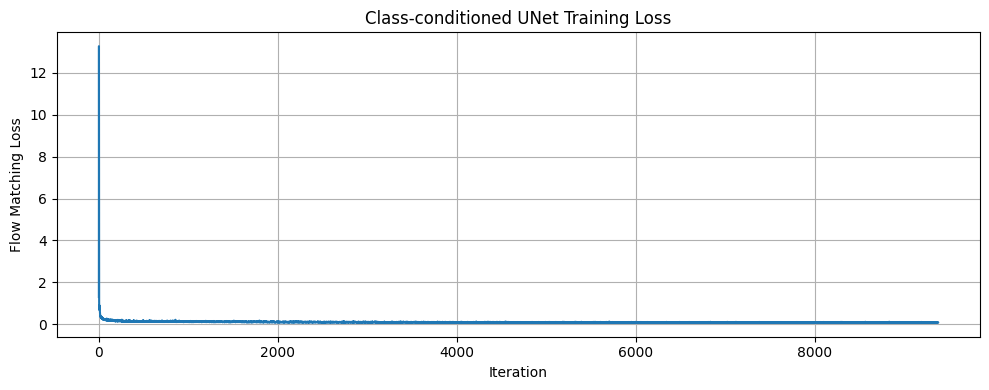

In [26]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Hyperparameters
cfg_batch_size  = 64
cfg_lr          = 1e-2
cfg_hidden_dim  = 64
cfg_num_epochs  = 10
cfg_num_ts      = 300
cfg_p_uncond    = 0.1
num_classes     = 10

cfg_train_loader = DataLoader(
    MNIST(root='./data', train=True, download=True, transform=ToTensor()),
    batch_size=cfg_batch_size, shuffle=True, num_workers=2
)

# Build model
cfg_unet = ClassConditionalUNet(
    in_channels=1, num_classes=num_classes, num_hiddens=cfg_hidden_dim
).to(device)
cfg_model = ClassConditionalFM(cfg_unet, num_ts=cfg_num_ts, p_uncond=cfg_p_uncond)

cfg_optimizer = torch.optim.Adam(cfg_unet.parameters(), lr=cfg_lr)
cfg_scheduler = torch.optim.lr_scheduler.ExponentialLR(
    cfg_optimizer, gamma=0.1 ** (1.0 / cfg_num_epochs)
)

cfg_train_losses = []
cfg_epoch_samples = {}

for epoch in range(cfg_num_epochs):
    cfg_unet.train()
    for images, labels in tqdm(cfg_train_loader, desc=f'CFG Epoch {epoch+1}/{cfg_num_epochs}'):
        images = images.to(device)
        labels = labels.to(device)

        loss = cfg_model(images, labels)
        cfg_optimizer.zero_grad()
        loss.backward()
        cfg_optimizer.step()
        cfg_train_losses.append(loss.item())

    cfg_scheduler.step()

    # Save samples at epoch 1, 5, 10
    if epoch + 1 in [1, 5, cfg_num_epochs]:
        # Generate 4 samples per digit class (4 x 10 = 40 images)
        all_samples = []
        for digit in range(10):
            c_batch = torch.full((4,), digit, dtype=torch.long, device=device)
            s = cfg_model.sample(c_batch, img_wh=(28, 28), guidance_scale=5.0, seed=42)
            all_samples.append(s.cpu())
        cfg_epoch_samples[epoch+1] = all_samples

# Plot training loss
plt.figure(figsize=(10, 4))
plt.plot(cfg_train_losses)
plt.xlabel('Iteration')
plt.ylabel('Flow Matching Loss')
plt.title('Class-conditioned UNet Training Loss')
plt.grid(True)
plt.tight_layout()
plt.show()

### Training Loss Interpretation
The class-conditioned flow-matching loss should generally decline as the model learns to combine label information with time conditioning. Some instability is expected because the classifier-free dropout randomly removes the class signal during training, which acts like a regularizer but adds variance to the loss.

# Part 2.6: Sampling from the Class-conditioned UNet

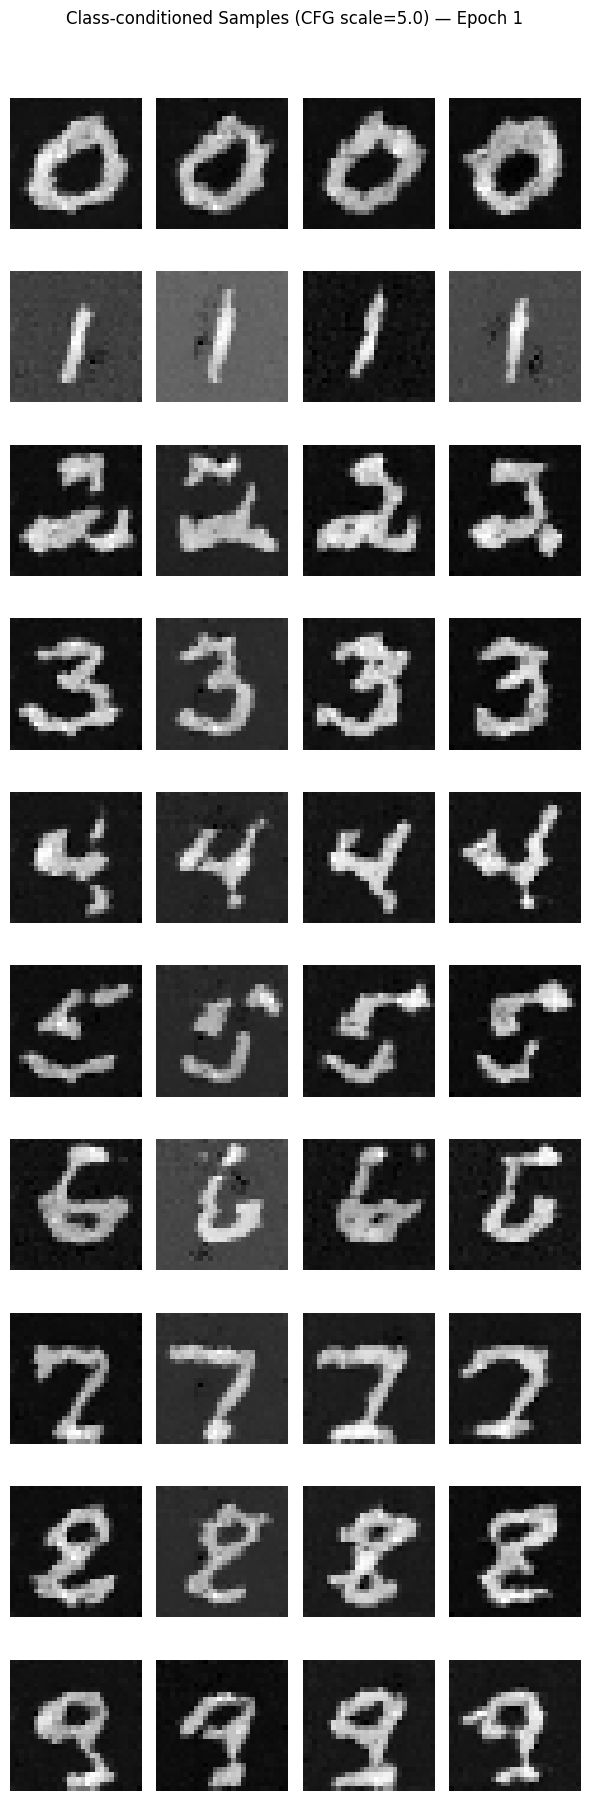

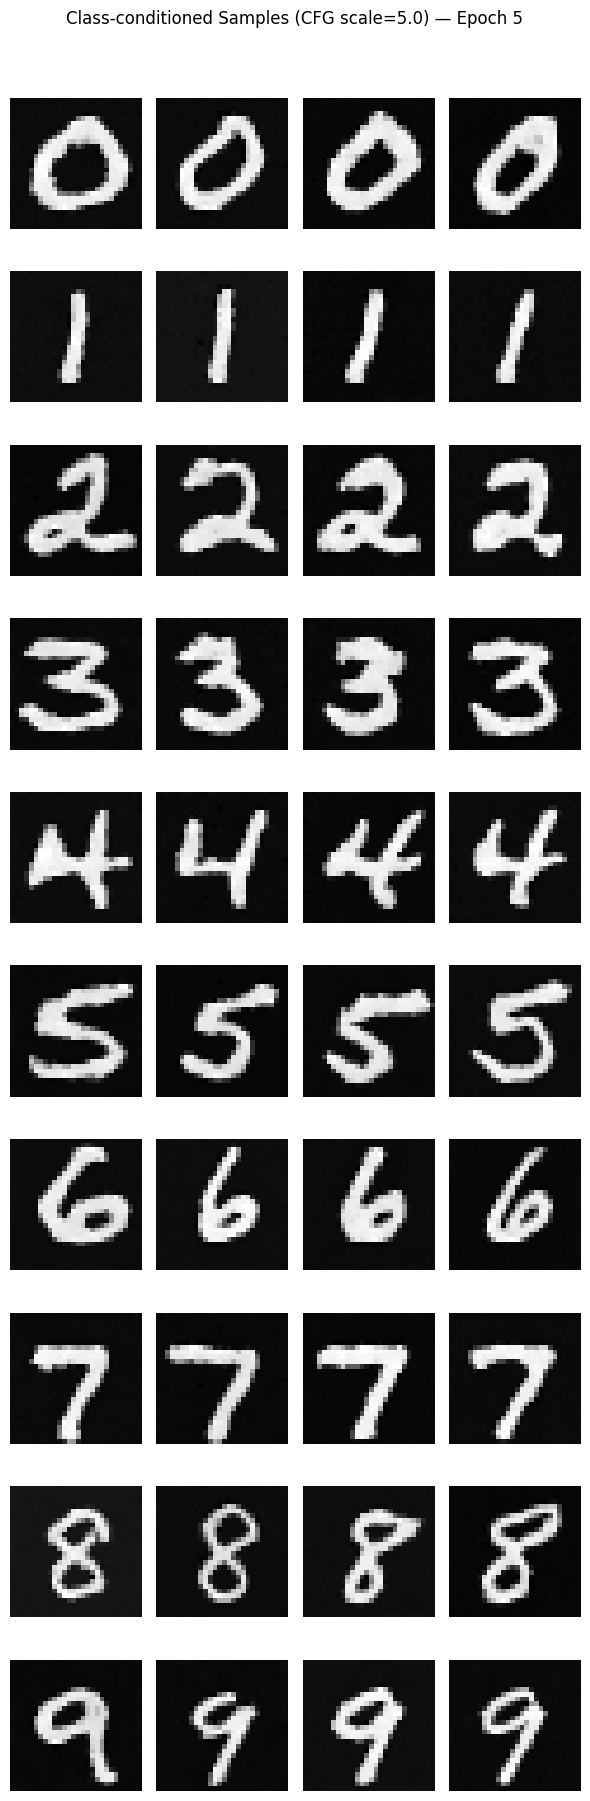

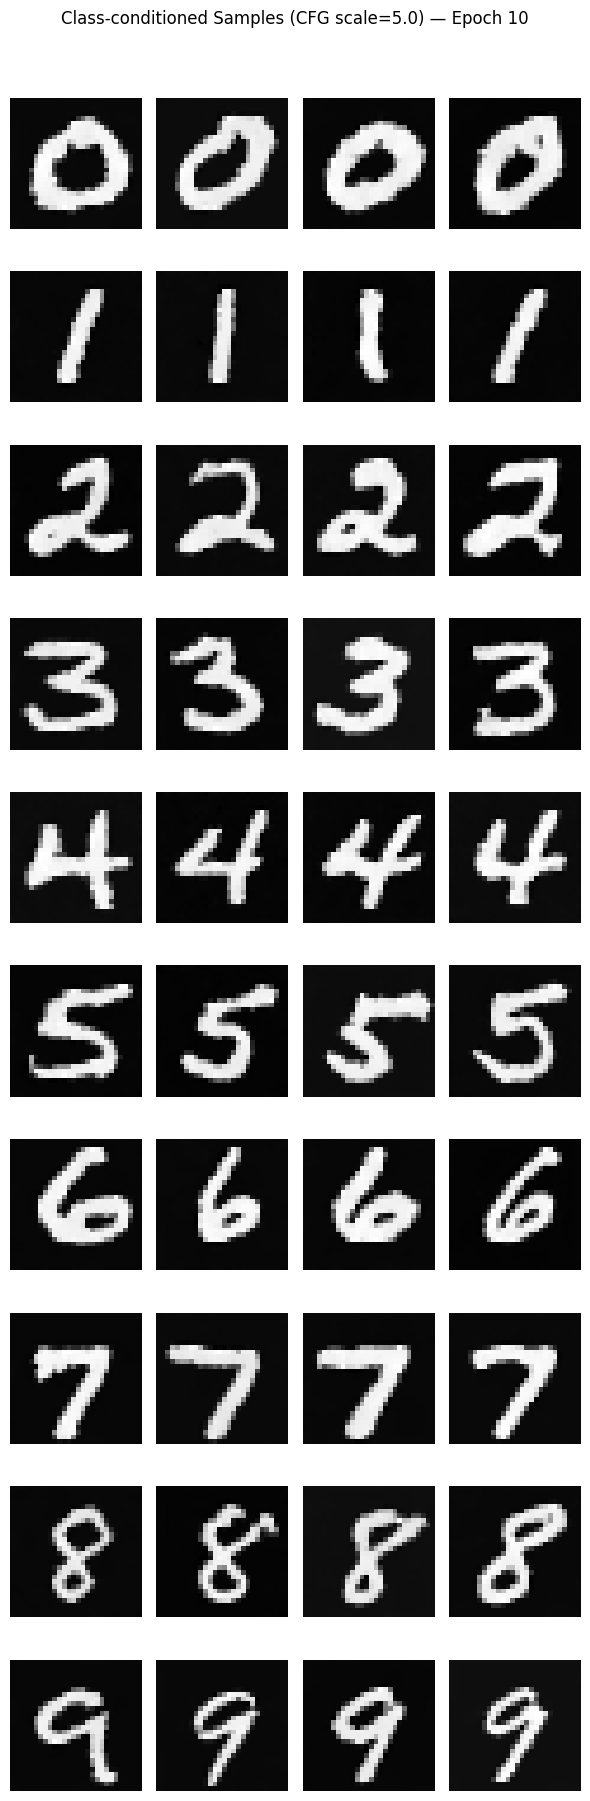

In [27]:

# Visualize 4 samples per digit for epochs 1, 5, 10
for ep, all_samples in cfg_epoch_samples.items():
    # all_samples: list of 10, each (4, 1, 28, 28)
    fig, axes = plt.subplots(10, 4, figsize=(6, 18))
    for digit in range(10):
        samples = all_samples[digit]  # (4, 1, 28, 28)
        for k in range(4):
            axes[digit, k].imshow(samples[k].squeeze(), cmap='gray')
            axes[digit, k].axis('off')
        axes[digit, 0].set_ylabel(str(digit), fontsize=12, rotation=0, labelpad=15)
    plt.suptitle(f'Class-conditioned Samples (CFG scale=5.0) — Epoch {ep}', y=1.01)
    plt.tight_layout()
    plt.show()
    plt.close(fig)

## Removing the LR Scheduler

To compensate for removing the exponential LR scheduler, we use a **warmup + cosine annealing** schedule instead.
The warmup prevents instability at the start while cosine annealing provides smooth decay without a steep exponential drop.
Alternatively, one can simply use a smaller constant learning rate (e.g. 1e-3) which is stable and often gives comparable results.


NoSched Epoch 10/10: 100%|██████████| 938/938 [00:13<00:00, 67.69it/s]


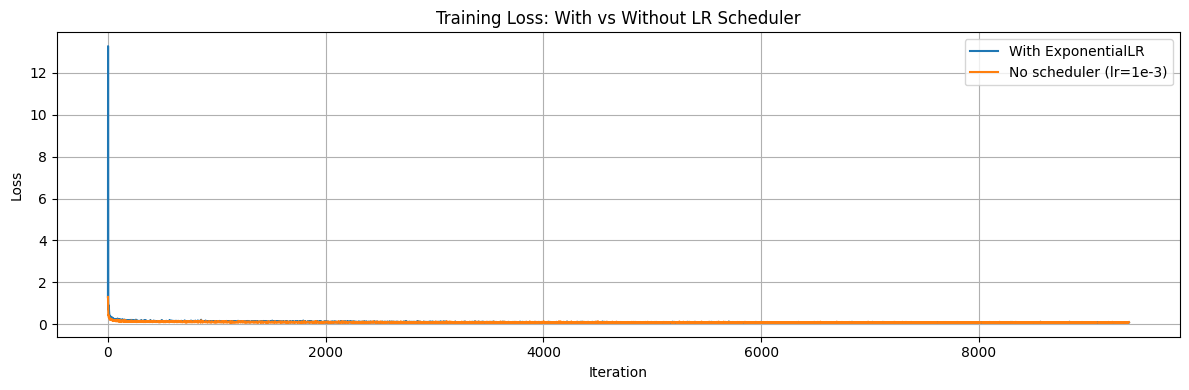

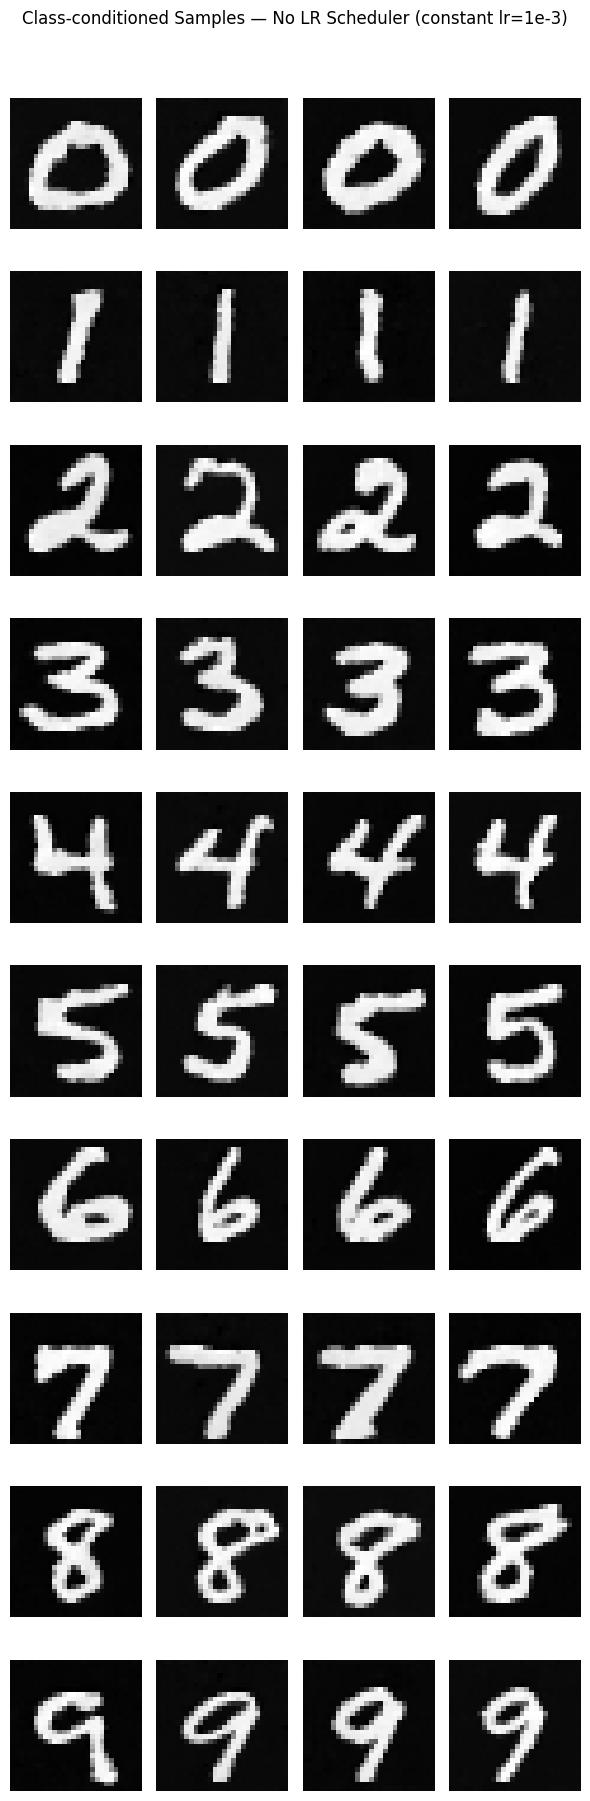

In [28]:
# Re-train without ExponentialLR scheduler.
# Instead we use a smaller constant LR to compensate.

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

no_sched_lr = 1e-3  # lower LR to compensate for no scheduler

ns_unet = ClassConditionalUNet(
    in_channels=1, num_classes=10, num_hiddens=64
).to(device)
ns_model = ClassConditionalFM(ns_unet, num_ts=300, p_uncond=0.1)
ns_optimizer = torch.optim.Adam(ns_unet.parameters(), lr=no_sched_lr)
# No scheduler!

ns_train_losses = []

for epoch in range(cfg_num_epochs):
    ns_unet.train()
    for images, labels in tqdm(cfg_train_loader, desc=f'NoSched Epoch {epoch+1}/{cfg_num_epochs}'):
        images = images.to(device)
        labels = labels.to(device)
        loss = ns_model(images, labels)
        ns_optimizer.zero_grad()
        loss.backward()
        ns_optimizer.step()
        ns_train_losses.append(loss.item())

# Compare loss curves
plt.figure(figsize=(12, 4))
plt.plot(cfg_train_losses, label='With ExponentialLR')
plt.plot(ns_train_losses,  label='No scheduler (lr=1e-3)')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Training Loss: With vs Without LR Scheduler')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Visualize no-scheduler samples
ns_all_samples = []
for digit in range(10):
    c_batch = torch.full((4,), digit, dtype=torch.long, device=device)
    s = ns_model.sample(c_batch, img_wh=(28, 28), guidance_scale=5.0, seed=42)
    ns_all_samples.append(s.cpu())

fig, axes = plt.subplots(10, 4, figsize=(6, 18))
for digit in range(10):
    samples = ns_all_samples[digit]
    for k in range(4):
        axes[digit, k].imshow(samples[k].squeeze(), cmap='gray')
        axes[digit, k].axis('off')
    axes[digit, 0].set_ylabel(str(digit), fontsize=12, rotation=0, labelpad=15)
plt.suptitle('Class-conditioned Samples — No LR Scheduler (constant lr=1e-3)', y=1.01)
plt.tight_layout()
plt.show()